# 🎓 CAPSTONE PROJECT

# CareerPilot
### AI-Powered Resume Intelligence & Career Matching System

---

**Course:** Stark AI — SSSC'26  
**Submitted By:** Sudiksha Das  
**Enrollment No.:** 19901172025  
**Institution:** Indira Gandhi Delhi Technological University For Women (IGDTUW)

---

## Final Project Submission

# 🚀 CareerPilot
## Multi-Agent AI Career Intelligence Platform

CareerPilot is an agentic AI system designed to help users make better
career decisions by analyzing their resumes, researching job opportunities,
identifying skill gaps, creating personalized learning plans, improving
job applications, and conducting role-specific interview preparation.

### Core Technologies
- Large Language Models (LLMs)
- Natural Language Processing (NLP)
- Retrieval-Augmented Generation (RAG)
- Semantic Search
- Embeddings
- Multi-Agent Systems
- Tool Calling
- AI Evaluation
- Python

### Core Agents
1. Resume Intelligence Agent
2. Job Research Agent
3. Job Matching Agent
4. Skill Gap Agent
5. Learning Agent
6. Resume Critic Agent
7. Interview Agent
8. Career Strategist Agent

## 1. Problem Statement

Students and early-career professionals often struggle to understand
whether their current skills and experience align with the requirements
of the roles they want to pursue.

Existing career platforms often provide generic recommendations but do
not continuously connect a candidate's resume, target roles, job
requirements, skill gaps, learning needs, and interview preparation.

CareerPilot aims to solve this problem by creating an AI-powered career
intelligence system that can analyze a candidate's profile, understand
job requirements, identify skill gaps, recommend relevant opportunities,
create personalized learning plans, and provide role-specific interview
preparation.

## 2. Objective

The main objective of CareerPilot is to build a multi-agent AI system
that can transform a user's resume and career goals into actionable,
personalized career guidance.

The system should be able to:

- Understand and structure information from a resume
- Analyze job descriptions and extract requirements
- Compare candidate skills with job requirements
- Generate explainable job-match scores
- Identify and prioritize skill gaps
- Retrieve relevant learning resources using RAG
- Generate personalized learning roadmaps
- Critique and improve resumes for specific job descriptions
- Conduct role-specific mock interviews
- Evaluate interview responses
- Combine all insights into a personalized career strategy

## 3. System Architecture

```text
                         USER
                           │
                           ▼
                  ┌─────────────────┐
                  │  Orchestrator   │
                  └────────┬────────┘
                           │
       ┌───────────────────┼───────────────────┐
       │                   │                   │
       ▼                   ▼                   ▼
 Resume Agent        Job Research Agent   Skill Gap Agent
       │                   │                   │
       ▼                   ▼                   ▼
 Candidate Profile    Job Requirements    Skill Analysis
       │                   │                   │
       └───────────────────┼───────────────────┘
                           │
              ┌────────────┴────────────┐
              ▼                         ▼
       Resume Critic              Learning Agent
              │                         │
              ▼                         ▼
       Resume Suggestions        Learning Roadmap
              │                         │
              └────────────┬────────────┘
                           ▼
                    Interview Agent
                           │
                           ▼
                    Career Strategist
                           │
                           ▼
                  Personalized Plan

In [1]:
!pip install -q huggingface_hub transformers sentence-transformers pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 30.0 MB/s eta 0:00:00


In [3]:
import os
import json
import re
import pymupdf

from huggingface_hub import InferenceClient
from sentence_transformers import SentenceTransformer

In [4]:
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError("HF_TOKEN not found. Add it to Colab Secrets.")

client = InferenceClient(
    token=HF_TOKEN
)

print("Hugging Face client initialized successfully.")

Hugging Face client initialized successfully.


In [5]:
response = client.chat_completion(
    model="meta-llama/Llama-3.1-8B-Instruct",
    messages=[
        {
            "role": "user",
            "content": "In one sentence, explain what an AI career assistant does."
        }
    ],
    max_tokens=100
)

print(response.choices[0].message.content)

An AI career assistant is a type of digital tool that uses machine learning algorithms to provide personalized career guidance, including job matching, resume building, and interview preparation, based on an individual's skills, experience, and goals.


In [6]:
MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

print("Model:", MODEL_NAME)

Model: meta-llama/Llama-3.1-8B-Instruct


In [7]:
def call_llm(prompt, max_tokens=500):
    response = client.chat_completion(
        model=MODEL_NAME,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_tokens=max_tokens
    )

    return response.choices[0].message.content

In [8]:
result = call_llm("Explain what a resume parser does.")
print(result)

A resume parser is a software application or service that takes a resume (in digital format) as input and extracts relevant information from it, typically in a structured format. The output is usually a collection of data points, such as job titles, skills, education, work experience, and other relevant details.

The resume parser uses various techniques, including:

1. **Natural Language Processing (NLP)**: The parser analyzes the text of the resume, identifying keywords, phrases, and sentence structures to extract meaningful information.
2. **Regular Expressions**: The parser uses regular expressions to identify patterns in the text, such as phone numbers, dates, and email addresses.
3. **Machine Learning**: Some parsers use machine learning algorithms to learn from a dataset of resumes and identify patterns and relationships between different data points.
4. **Rule-based parsing**: The parser applies pre-defined rules to extract information from the resume, such as extracting job ti

# 🤖 CareerPilot — Multi-Agent Architecture

CareerPilot is designed as a multi-agent AI career assistant.

The system will contain specialized agents, where each agent is responsible
for a specific part of the career-analysis workflow.

### Planned Agents

1. 📄 Resume Intelligence Agent
   - Extracts and structures information from a resume
   - Identifies skills, education, experience, projects, and certifications

2. 🎯 Job Matching Agent
   - Compares the candidate's profile with a job description
   - Identifies matching and missing skills

3. 📊 Resume Analysis Agent
   - Evaluates resume strengths and weaknesses
   - Suggests areas for improvement

4. 📝 Resume Improvement Agent
   - Generates suggestions to improve resume content
   - Helps rewrite weak sections

5. 🎤 Interview Preparation Agent
   - Generates interview questions based on the candidate's profile
   - Provides personalized preparation guidance

### Workflow

Resume + Job Description
        ↓
Resume Intelligence Agent
        ↓
Structured Candidate Profile
        ↓
Job Matching Agent
        ↓
Resume Analysis Agent
        ↓
Resume Improvement Agent
        ↓
Interview Preparation Agent
        ↓
Personalized Career Guidance

# 📄 Resume Input

The first step in CareerPilot is to accept a candidate's resume.

For this prototype, we will upload a resume PDF and extract its text before
sending the relevant information to the Resume Intelligence Agent.

In [9]:
from google.colab import files

uploaded = files.upload()

resume_path = next(iter(uploaded))

print("✅ Resume uploaded successfully.")
print("File:", resume_path)

Saving Sudiksha_Das_Resume_Final_V2.pdf to Sudiksha_Das_Resume_Final_V2.pdf
✅ Resume uploaded successfully.
File: Sudiksha_Das_Resume_Final_V2.pdf


In [10]:
import pymupdf

doc = pymupdf.open(resume_path)

resume_text = ""

for page in doc:
    resume_text += page.get_text()

doc.close()

print("✅ Resume text extracted successfully.")
print(f"Characters extracted: {len(resume_text)}")

✅ Resume text extracted successfully.
Characters extracted: 1966


In [11]:
print(resume_text[:5000])

SUDIKSHA DAS
New Delhi, Delhi, India  |  +91 8868902224  |  sudikshal99btcseai25@igdtuw.ac.in
linkedin.com/in/sudiksha-das  |  github.com/sudiksha8639-debug
EDUCATION
Indira Gandhi Delhi Technical University for Women (IGDTUW)
2025 – 2029 (Expected)
B.Tech in Computer Science and Engineering AI (CSE-AI)  |  New Delhi, India
Semester 1 SGPA: 8.48  •  Semester 2 SGPA: 9.43 
EXPERIENCE
Machine Learning & Generative AI Intern
June 6, 2026 – July 30, 2026
IGDTUW × Anveshan Foundation
Developed and evaluated machine learning workflows using Python.
Exploring and integrating modern AI tooling (LLMs, generative pipelines) to build practical, functioning
prototypes.
Collaborating with a small technical team to design, test, and iterate on AI-driven solutions.
PROJECTS
Smart Cal – AI-Powered Health & Nutrition Assistant
Python, React, FastAPI, Scikit-learn, Pandas, NumPy
Designed and developed an AI-powered health assistant that provides personalized nutrition
recommendations, calorie estimation

In [12]:
import re

def clean_resume_text(text):
    # Replace multiple spaces/tabs with a single space
    text = re.sub(r'[ \t]+', ' ', text)

    # Remove excessive blank lines
    text = re.sub(r'\n\s*\n+', '\n\n', text)

    # Remove stray bullet characters
    text = re.sub(r'^\s*[•·]\s*$', '', text, flags=re.MULTILINE)

    # Remove leading/trailing whitespace from each line
    text = '\n'.join(line.strip() for line in text.splitlines())

    return text.strip()


cleaned_resume_text = clean_resume_text(resume_text)

print("✅ Resume text cleaned successfully.")
print(f"Characters before cleaning: {len(resume_text)}")
print(f"Characters after cleaning:  {len(cleaned_resume_text)}")

✅ Resume text cleaned successfully.
Characters before cleaning: 1966
Characters after cleaning:  1930


In [13]:
print(cleaned_resume_text)

SUDIKSHA DAS
New Delhi, Delhi, India | +91 8868902224 | sudikshal99btcseai25@igdtuw.ac.in
linkedin.com/in/sudiksha-das | github.com/sudiksha8639-debug
EDUCATION
Indira Gandhi Delhi Technical University for Women (IGDTUW)
2025 – 2029 (Expected)
B.Tech in Computer Science and Engineering AI (CSE-AI) | New Delhi, India
Semester 1 SGPA: 8.48 • Semester 2 SGPA: 9.43
EXPERIENCE
Machine Learning & Generative AI Intern
June 6, 2026 – July 30, 2026
IGDTUW × Anveshan Foundation
Developed and evaluated machine learning workflows using Python.
Exploring and integrating modern AI tooling (LLMs, generative pipelines) to build practical, functioning
prototypes.
Collaborating with a small technical team to design, test, and iterate on AI-driven solutions.
PROJECTS
Smart Cal – AI-Powered Health & Nutrition Assistant
Python, React, FastAPI, Scikit-learn, Pandas, NumPy
Designed and developed an AI-powered health assistant that provides personalized nutrition
recommendations, calorie estimation, hydration

In [14]:
def resume_intelligence_agent(resume_text):
    prompt = f"""
You are the Resume Intelligence Agent of CareerPilot.

Your task is to analyze the candidate's resume and extract useful career-related
information from it.

Identify the following:

1. Candidate name
2. Education
3. Work experience
4. Projects
5. Technical skills
6. Tools and technologies
7. Achievements and involvement
8. Potential career roles based ONLY on the information present in the resume

Do not invent information that is not present in the resume.

Resume:
--------------------
{resume_text}
--------------------

Provide the result in a clear and structured format.
"""

    return call_llm(prompt, max_tokens=800)

In [15]:
resume_profile = resume_intelligence_agent(cleaned_resume_text)

print(resume_profile)

**Candidate Analysis Report**

**1. Candidate Name:** SUDIKSHA DAS

**2. Education:**

* Currently pursuing B.Tech in Computer Science and Engineering AI (CSE-AI) at Indira Gandhi Delhi Technical University for Women (IGDTUW)
* Expected graduation date: 2029
* Academic performance:
	+ Semester 1 SGPA: 8.48
	+ Semester 2 SGPA: 9.43

**3. Work Experience:**

* Machine Learning & Generative AI Intern at IGDTUW × Anveshan Foundation
	+ Duration: June 6, 2026 – July 30, 2026
	+ Responsibilities:
		- Developed and evaluated machine learning workflows using Python
		- Explored and integrated modern AI tooling (LLMs, generative pipelines) to build practical, functioning prototypes
		- Collaborated with a small technical team to design, test, and iterate on AI-driven solutions

**4. Projects:**

* **Smart Cal – AI-Powered Health & Nutrition Assistant**
	+ Technologies used: Python, React, FastAPI, Scikit-learn, Pandas, NumPy
	+ Description: Developed an AI-powered health assistant that provides

In [16]:
import json

def resume_intelligence_agent(resume_text):
    prompt = f"""
You are the Resume Intelligence Agent of CareerPilot.

Analyze the resume and extract information into the exact JSON structure below.

{{
    "name": "",
    "education": [],
    "experience": [],
    "projects": [],
    "skills": [],
    "tools": [],
    "achievements": [],
    "potential_roles": []
}}

Rules:
- Return ONLY valid JSON.
- Do not use markdown.
- Do not add explanations outside the JSON.
- Do not invent information.
- Use empty lists when information is unavailable.
- Keep the extracted information concise but useful.

Resume:
--------------------
{resume_text}
--------------------
"""

    response = call_llm(prompt, max_tokens=1200)

    return response

In [17]:
resume_profile_raw = resume_intelligence_agent(cleaned_resume_text)

print(resume_profile_raw)

{
    "name": "Sudiksha Das",
    "education": [
        {
            "institution": "Indira Gandhi Delhi Technical University for Women (IGDTUW)",
            "program": "B.Tech in Computer Science and Engineering AI (CSE-AI)",
            "expectedGraduationYear": 2029,
            "semesterGPA": [
                {
                    "semester": 1,
                    "SGPA": 8.48
                },
                {
                    "semester": 2,
                    "SGPA": 9.43
                }
            ]
        }
    ],
    "experience": [
        {
            "position": "Machine Learning & Generative AI Intern",
            "company": "IGDTUW × Anveshan Foundation",
            "dates": "June 6, 2026 – July 30, 2026",
            "responsibilities": [
                "Developed and evaluated machine learning workflows using Python.",
                "Exploring and integrating modern AI tooling (LLMs, generative pipelines) to build practical, functioning prototypes."

In [18]:
resume_profile = json.loads(resume_profile_raw)

print("✅ Resume successfully converted into structured data.")
print(type(resume_profile))

✅ Resume successfully converted into structured data.
<class 'dict'>


In [19]:
print(resume_profile.keys())

dict_keys(['name', 'education', 'experience', 'projects', 'skills', 'achievements', 'potential_roles'])


In [20]:
print("Candidate:", resume_profile["name"])
print("Skills:", resume_profile["skills"])
print("Projects:", resume_profile["projects"])

Candidate: Sudiksha Das
Skills: [{'category': 'Core Roles', 'roles': ['AI/ML Developer', 'Frontend Developer', 'UI/UX Designer']}, {'category': 'Languages', 'languages': ['Python', 'C++', 'Java', 'JavaScript']}, {'category': 'AI / ML & Data', 'technologies': ['NumPy', 'Pandas', 'Matplotlib', 'Scikit-learn']}, {'category': 'AI Tools', 'tools': ['Cursor', 'Claude', 'Gemini', 'Google AI Studio', 'NotebookLM', 'Eleven Labs']}, {'category': 'Tools & Platforms', 'tools': ['Git', 'GitHub', 'VS Code', 'Google Colab', 'Canva', 'Figma']}]
Projects: [{'name': 'Smart Cal – AI-Powered Health & Nutrition Assistant', 'technologies': ['Python', 'React', 'FastAPI', 'Scikit-learn', 'Pandas', 'NumPy'], 'description': 'Designed and developed an AI-powered health assistant that provides personalized nutrition recommendations, calorie estimation, hydration tracking, and wellness insights for students.'}, {'name': 'Lawgic – Know Your Rights', 'technologies': ['React', 'TypeScript', 'Vite', 'OpenStreetMap API

In [21]:
required_fields = [
    "name",
    "education",
    "experience",
    "projects",
    "skills",
    "tools",
    "achievements",
    "potential_roles"
]

missing_fields = [
    field for field in required_fields
    if field not in resume_profile
]

if missing_fields:
    print("⚠️ Missing fields:", missing_fields)
else:
    print("✅ Resume profile contains all required fields.")

⚠️ Missing fields: ['tools']


In [22]:
for field in required_fields:
    if field not in resume_profile:
        resume_profile[field] = []

print("✅ Resume profile normalized.")
print(resume_profile.keys())

✅ Resume profile normalized.
dict_keys(['name', 'education', 'experience', 'projects', 'skills', 'achievements', 'potential_roles', 'tools'])


In [23]:
print("Tools:", resume_profile["tools"])

Tools: []


# 💼 Job Description Input

The Job Matching Agent compares the candidate's structured resume profile
against a target job description.

It will identify:
- Matching skills
- Missing skills
- Relevant experience
- Relevant projects
- Overall fit

In [24]:
job_description = """
AI/ML Intern

We are looking for an AI/ML Intern to join our team.

Requirements:
- Strong Python programming skills
- Familiarity with Machine Learning and Generative AI
- Experience with NumPy, Pandas and Scikit-learn
- Understanding of LLMs and AI tools
- Experience building AI/ML projects
- Familiarity with Git and GitHub
- Good problem-solving and communication skills

Preferred:
- Experience with FastAPI
- Experience with React or frontend technologies
- Familiarity with Generative AI applications
"""

print(job_description)


AI/ML Intern

We are looking for an AI/ML Intern to join our team.

Requirements:
- Strong Python programming skills
- Familiarity with Machine Learning and Generative AI
- Experience with NumPy, Pandas and Scikit-learn
- Understanding of LLMs and AI tools
- Experience building AI/ML projects
- Familiarity with Git and GitHub
- Good problem-solving and communication skills

Preferred:
- Experience with FastAPI
- Experience with React or frontend technologies
- Familiarity with Generative AI applications



In [25]:
def job_matching_agent(candidate_profile, job_description):

    prompt = f"""
You are the Job Matching Agent of CareerPilot.

Your task is to compare a candidate's structured resume profile
against a job description.

Candidate Profile:
--------------------
{json.dumps(candidate_profile, indent=2)}
--------------------

Job Description:
--------------------
{job_description}
--------------------

Analyze:

1. Matching skills
2. Missing or weak skills
3. Relevant experience
4. Relevant projects
5. Strengths for this role
6. Areas that could be improved
7. Overall match score from 0 to 100

Return ONLY valid JSON using this structure:

{{
    "match_score": 0,
    "matching_skills": [],
    "missing_skills": [],
    "relevant_experience": [],
    "relevant_projects": [],
    "strengths": [],
    "improvement_areas": []
}}

Do not invent information about the candidate.
"""

    response = call_llm(prompt, max_tokens=1200)

    return response

In [26]:
job_match_raw = job_matching_agent(
    resume_profile,
    job_description
)

print(job_match_raw)

Here is the analysis:

```json
{
    "match_score": 85,
    "matching_skills": [
        "Python programming skills",
        "Machine Learning and Generative AI",
        "NumPy",
        "Pandas",
        "Scikit-learn",
        "Git",
        "GitHub"
    ],
    "missing_skills": [
        "Experience with FastAPI (although mentioned in projects)",
        "Experience with React or frontend technologies (although mentioned in projects)",
        "Experience with Generative AI applications (although mentioned in projects)"
    ],
    "relevant_experience": [
        "Machine Learning & Generative AI Intern at IGDTUW × Anveshan Foundation",
        "Experience building AI/ML projects"
    ],
    "relevant_projects": [
        "Smart Cal – AI-Powered Health & Nutrition Assistant",
        "Lawgic – Know Your Rights"
    ],
    "strengths": [
        "Strong Python programming skills",
        "Experience with Machine Learning and Generative AI",
        "Good problem-solving and commun

In [28]:
import re
import json

def extract_json(response):
    # Remove Markdown code fences if present
    response = re.sub(r"```json\s*", "", response)
    response = re.sub(r"```\s*", "", response)

    # Find the JSON object inside the response
    match = re.search(r"\{.*\}", response, re.DOTALL)

    if not match:
        raise ValueError("No valid JSON object found in LLM response.")

    json_text = match.group(0)

    return json.loads(json_text)


job_match = extract_json(job_match_raw)

print("✅ Job matching response converted to structured data.")
print(job_match.keys())

✅ Job matching response converted to structured data.
dict_keys(['match_score', 'matching_skills', 'missing_skills', 'relevant_experience', 'relevant_projects', 'strengths', 'improvement_areas'])


In [29]:
required_match_fields = [
    "match_score",
    "matching_skills",
    "missing_skills",
    "relevant_experience",
    "relevant_projects",
    "strengths",
    "improvement_areas"
]

missing_match_fields = [
    field for field in required_match_fields
    if field not in job_match
]

if missing_match_fields:
    print("⚠️ Missing fields:", missing_match_fields)
else:
    print("✅ Job match contains all required fields.")

✅ Job match contains all required fields.


In [30]:
print(f"🎯 Overall Match Score: {job_match['match_score']}/100")

print("\n✅ Matching Skills:")
for skill in job_match["matching_skills"]:
    print("-", skill)

print("\n⚠️ Missing / Weak Skills:")
for skill in job_match["missing_skills"]:
    print("-", skill)

print("\n💼 Relevant Experience:")
for experience in job_match["relevant_experience"]:
    print("-", experience)

print("\n🚀 Relevant Projects:")
for project in job_match["relevant_projects"]:
    print("-", project)

🎯 Overall Match Score: 85/100

✅ Matching Skills:
- Python programming skills
- Machine Learning and Generative AI
- NumPy
- Pandas
- Scikit-learn
- Git
- GitHub

⚠️ Missing / Weak Skills:
- Experience with FastAPI (although mentioned in projects)
- Experience with React or frontend technologies (although mentioned in projects)
- Experience with Generative AI applications (although mentioned in projects)

💼 Relevant Experience:
- Machine Learning & Generative AI Intern at IGDTUW × Anveshan Foundation
- Experience building AI/ML projects

🚀 Relevant Projects:
- Smart Cal – AI-Powered Health & Nutrition Assistant
- Lawgic – Know Your Rights


In [31]:
candidate_skills = set()

for category in resume_profile["skills"]:
    for key, values in category.items():
        if isinstance(values, list):
            for value in values:
                candidate_skills.add(value.lower())

print("✅ Candidate skills extracted:")
for skill in sorted(candidate_skills):
    print("-", skill)

✅ Candidate skills extracted:
- ai/ml developer
- c++
- canva
- claude
- cursor
- eleven labs
- figma
- frontend developer
- gemini
- git
- github
- google ai studio
- google colab
- java
- javascript
- matplotlib
- notebooklm
- numpy
- pandas
- python
- scikit-learn
- ui/ux designer
- vs code


In [32]:
job_required_skills = [
    "Python",
    "Machine Learning",
    "Generative AI",
    "NumPy",
    "Pandas",
    "Scikit-learn",
    "LLMs",
    "Git",
    "GitHub",
    "FastAPI",
    "React"
]

print("✅ Job requirements defined.")

✅ Job requirements defined.


In [33]:
matched_skills = []
missing_skills = []

for required_skill in job_required_skills:
    required_lower = required_skill.lower()

    if required_lower in candidate_skills:
        matched_skills.append(required_skill)
    else:
        missing_skills.append(required_skill)

print("✅ Deterministic skill check completed.")

print("\nMatching Skills:")
for skill in matched_skills:
    print("-", skill)

print("\nMissing Skills:")
for skill in missing_skills:
    print("-", skill)

✅ Deterministic skill check completed.

Matching Skills:
- Python
- NumPy
- Pandas
- Scikit-learn
- Git
- GitHub

Missing Skills:
- Machine Learning
- Generative AI
- LLMs
- FastAPI
- React


In [34]:
!pip install -q sentence-transformers

In [35]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

print("✅ Embedding model loaded successfully.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Embedding model loaded successfully.


In [36]:
from sentence_transformers.util import cos_sim

def semantic_similarity(text1, text2):
    embedding1 = embedding_model.encode(text1, convert_to_tensor=True)
    embedding2 = embedding_model.encode(text2, convert_to_tensor=True)

    similarity = cos_sim(embedding1, embedding2)

    return float(similarity.item())

In [37]:
score = semantic_similarity(
    "Machine Learning",
    "Machine Learning & Generative AI Intern"
)

print(f"Semantic similarity: {score:.3f}")

Semantic similarity: 0.476


In [38]:
candidate_evidence = set(candidate_skills)

for project in resume_profile["projects"]:
    for technology in project.get("technologies", []):
        candidate_evidence.add(technology.lower())

print("✅ Candidate skill evidence collected.")

for item in sorted(candidate_evidence):
    print("-", item)

✅ Candidate skill evidence collected.
- ai/ml developer
- c++
- canva
- claude
- cursor
- eleven labs
- fastapi
- figma
- frontend developer
- gemini
- git
- github
- google ai studio
- google colab
- java
- javascript
- matplotlib
- notebooklm
- numpy
- openstreetmap api
- pandas
- python
- react
- scikit-learn
- typescript
- ui/ux designer
- vite
- vs code


In [39]:
def best_semantic_match(required_skill, candidate_evidence):
    best_score = -1
    best_match = None

    required_embedding = embedding_model.encode(
        required_skill,
        convert_to_tensor=True
    )

    for evidence in candidate_evidence:
        evidence_embedding = embedding_model.encode(
            evidence,
            convert_to_tensor=True
        )

        score = float(
            cos_sim(required_embedding, evidence_embedding).item()
        )

        if score > best_score:
            best_score = score
            best_match = evidence

    return best_match, best_score

In [40]:
test_skills = [
    "Machine Learning",
    "Generative AI",
    "LLMs",
    "FastAPI",
    "React"
]

for skill in test_skills:
    match, score = best_semantic_match(
        skill,
        candidate_evidence
    )

    print(f"{skill} → {match} ({score:.3f})")

Machine Learning → ai/ml developer (0.439)
Generative AI → google ai studio (0.527)
LLMs → canva (0.313)
FastAPI → fastapi (1.000)
React → react (1.000)


In [41]:
SEMANTIC_THRESHOLD = 0.65

In [42]:
def best_semantic_match(required_skill, candidate_evidence):
    best_score = -1
    best_match = None

    required_embedding = embedding_model.encode(
        required_skill,
        convert_to_tensor=True
    )

    for evidence in candidate_evidence:
        evidence_embedding = embedding_model.encode(
            evidence,
            convert_to_tensor=True
        )

        score = float(
            cos_sim(required_embedding, evidence_embedding).item()
        )

        if score > best_score:
            best_score = score
            best_match = evidence

    if best_score >= SEMANTIC_THRESHOLD:
        return best_match, best_score

    return None, best_score

In [43]:
for skill in test_skills:
    match, score = best_semantic_match(
        skill,
        candidate_evidence
    )

    if match:
        print(f"{skill} → {match} ({score:.3f})")
    else:
        print(f"{skill} → No strong semantic match ({score:.3f})")

Machine Learning → No strong semantic match (0.439)
Generative AI → No strong semantic match (0.527)
LLMs → No strong semantic match (0.313)
FastAPI → fastapi (1.000)
React → react (1.000)


In [44]:
candidate_evidence = set(candidate_skills)

# Add project technologies and descriptions
for project in resume_profile["projects"]:
    for technology in project.get("technologies", []):
        candidate_evidence.add(technology.lower())

    if project.get("description"):
        candidate_evidence.add(project["description"].lower())


# Add experience information
for experience in resume_profile["experience"]:
    if isinstance(experience, dict):
        for value in experience.values():
            if isinstance(value, str):
                candidate_evidence.add(value.lower())
            elif isinstance(value, list):
                for item in value:
                    if isinstance(item, str):
                        candidate_evidence.add(item.lower())
    elif isinstance(experience, str):
        candidate_evidence.add(experience.lower())


print("✅ Rich candidate evidence created.")
print(f"Total evidence items: {len(candidate_evidence)}")

✅ Rich candidate evidence created.
Total evidence items: 36


In [45]:
for skill in test_skills:
    match, score = best_semantic_match(
        skill,
        candidate_evidence
    )

    if match:
        print(f"{skill} → {match} ({score:.3f})")
    else:
        print(f"{skill} → No strong semantic match ({score:.3f})")

Machine Learning → No strong semantic match (0.476)
Generative AI → machine learning & generative ai intern (0.774)
LLMs → No strong semantic match (0.313)
FastAPI → fastapi (1.000)
React → react (1.000)


In [46]:
def direct_skill_match(required_skill, candidate_evidence):
    required_skill = required_skill.lower()

    matches = []

    for evidence in candidate_evidence:
        if required_skill in evidence:
            matches.append(evidence)

    return matches

In [47]:
for skill in test_skills:
    matches = direct_skill_match(skill, candidate_evidence)

    if matches:
        print(f"\n{skill} → DIRECT MATCH")
        for match in matches[:2]:
            print("  Evidence:", match)
    else:
        print(f"\n{skill} → No direct match")


Machine Learning → DIRECT MATCH
  Evidence: machine learning & generative ai intern
  Evidence: developed and evaluated machine learning workflows using python.

Generative AI → DIRECT MATCH
  Evidence: machine learning & generative ai intern

LLMs → DIRECT MATCH
  Evidence: exploring and integrating modern ai tooling (llms, generative pipelines) to build practical, functioning prototypes.

FastAPI → DIRECT MATCH
  Evidence: fastapi

React → DIRECT MATCH
  Evidence: react


In [48]:
def hybrid_skill_match(required_skill, candidate_evidence):
    # Step 1: Direct matching
    direct_matches = direct_skill_match(
        required_skill,
        candidate_evidence
    )

    if direct_matches:
        return {
            "skill": required_skill,
            "status": "Matched",
            "method": "Direct",
            "evidence": direct_matches[0],
            "score": 1.0
        }

    # Step 2: Semantic matching
    best_match, best_score = best_semantic_match(
        required_skill,
        candidate_evidence
    )

    if best_match:
        return {
            "skill": required_skill,
            "status": "Matched",
            "method": "Semantic",
            "evidence": best_match,
            "score": best_score
        }

    # Step 3: No reliable match
    return {
        "skill": required_skill,
        "status": "Not matched",
        "method": "None",
        "evidence": None,
        "score": best_score
    }

In [49]:
hybrid_results = []

for skill in job_required_skills:
    result = hybrid_skill_match(
        skill,
        candidate_evidence
    )

    hybrid_results.append(result)

    print(
        f"{skill} → "
        f"{result['status']} "
        f"({result['method']}) "
        f"[{result['score']:.3f}]"
    )

Python → Matched (Direct) [1.000]
Machine Learning → Matched (Direct) [1.000]
Generative AI → Matched (Direct) [1.000]
NumPy → Matched (Direct) [1.000]
Pandas → Matched (Direct) [1.000]
Scikit-learn → Matched (Direct) [1.000]
LLMs → Matched (Direct) [1.000]
Git → Matched (Direct) [1.000]
GitHub → Matched (Direct) [1.000]
FastAPI → Matched (Direct) [1.000]
React → Matched (Direct) [1.000]


In [50]:
matched_count = sum(
    1 for result in hybrid_results
    if result["status"] == "Matched"
)

total_required = len(job_required_skills)

verified_skill_score = (
    matched_count / total_required
) * 100

print(f"🎯 Verified Skill Match: {verified_skill_score:.1f}%")
print(f"Matched: {matched_count}/{total_required}")

🎯 Verified Skill Match: 100.0%
Matched: 11/11


In [51]:
llm_score = job_match["match_score"]

print(f"🤖 LLM Match Score:      {llm_score}/100")
print(f"🔍 Verified Skill Score: {verified_skill_score:.1f}/100")

🤖 LLM Match Score:      85/100
🔍 Verified Skill Score: 100.0/100


In [52]:
combined_score = (
    0.60 * verified_skill_score +
    0.40 * llm_score
)

print(f"🎯 CareerPilot Combined Match Score: {combined_score:.1f}/100")

🎯 CareerPilot Combined Match Score: 94.0/100


# 📊 Resume Analysis Agent

The Resume Analysis Agent evaluates the candidate's resume independently.

It looks for:
- Resume strengths
- Weak or unclear areas
- Missing information
- Technical presentation
- Project descriptions
- Experience descriptions
- Areas for improvement

The agent should only make observations supported by the resume.

In [55]:
def resume_analysis_agent(resume_text, candidate_profile):

    prompt = f"""
You are the Resume Analysis Agent of CareerPilot.

Analyze the candidate's resume and provide constructive feedback.

Candidate Profile:
--------------------
{json.dumps(candidate_profile, indent=2)}
--------------------

Resume:
--------------------
{resume_text}
--------------------

Evaluate:

1. Strengths of the resume
2. Weaknesses or unclear areas
3. Missing information
4. Skills that could be presented better
5. Project description quality
6. Experience description quality
7. Specific improvement suggestions

Do not invent information.
Do not criticize information that is not required.
Focus on practical improvements that would make the resume stronger.

Return ONLY valid JSON.

Use these keys:
strengths
weaknesses
missing_information
skills_to_highlight
project_feedback
experience_feedback
improvement_suggestions
"""

    response = call_llm(prompt, max_tokens=1200)

    return response

In [56]:
resume_analysis_raw = resume_analysis_agent(
    cleaned_resume_text,
    resume_profile
)

print(resume_analysis_raw)

Here's the evaluation of the resume:

```json
{
  "strengths": [
    {
      "category": "Education",
      "description": "Strong educational background in Computer Science and Engineering AI (CSE-AI) from Indira Gandhi Delhi Technical University for Women (IGDTUW)"
    },
    {
      "category": "Experience",
      "description": "Gained practical experience as a Machine Learning & Generative AI Intern at IGDTUW × Anveshan Foundation"
    },
    {
      "category": "Projects",
      "description": "Developed two impressive projects, Smart Cal and Lawgic, showcasing AI-powered health and legal assistance capabilities"
    },
    {
      "category": "Skills",
      "description": "Proficient in a range of programming languages, including Python, C++, Java, and JavaScript, as well as AI and data technologies like NumPy, Pandas, and Scikit-learn"
    }
  ],
  "weaknesses": [
    {
      "category": "Experience",
      "description": "The experience section could be more detailed and spec

In [57]:
resume_analysis = extract_json(resume_analysis_raw)

print("✅ Resume analysis converted to structured data.")
print(resume_analysis.keys())

✅ Resume analysis converted to structured data.
dict_keys(['strengths', 'weaknesses', 'missing_information', 'skills_to_highlight', 'project_feedback', 'experience_feedback', 'improvement_suggestions'])


In [58]:
required_analysis_fields = [
    "strengths",
    "weaknesses",
    "missing_information",
    "skills_to_highlight",
    "project_feedback",
    "experience_feedback",
    "improvement_suggestions"
]

missing_analysis_fields = [
    field
    for field in required_analysis_fields
    if field not in resume_analysis
]

if missing_analysis_fields:
    print("⚠️ Missing fields:", missing_analysis_fields)
else:
    print("✅ Resume analysis contains all required fields.")

✅ Resume analysis contains all required fields.


In [59]:
print("💪 STRENGTHS")
for item in resume_analysis["strengths"]:
    print("-", item["description"])

print("\n⚠️ WEAKNESSES")
for item in resume_analysis["weaknesses"]:
    print("-", item["description"])

print("\n🔧 IMPROVEMENT SUGGESTIONS")
for item in resume_analysis["improvement_suggestions"]:
    print("-", item["description"])

💪 STRENGTHS
- Strong educational background in Computer Science and Engineering AI (CSE-AI) from Indira Gandhi Delhi Technical University for Women (IGDTUW)
- Gained practical experience as a Machine Learning & Generative AI Intern at IGDTUW × Anveshan Foundation
- Developed two impressive projects, Smart Cal and Lawgic, showcasing AI-powered health and legal assistance capabilities
- Proficient in a range of programming languages, including Python, C++, Java, and JavaScript, as well as AI and data technologies like NumPy, Pandas, and Scikit-learn

⚠️ WEAKNESSES
- The experience section could be more detailed and specific, with clear achievements and contributions
- While the projects are impressive, the descriptions could be more concise and focused on the key benefits and outcomes
- The skills section is extensive, but some categories (e.g., 'AI Tools') might be less relevant to the candidate's overall strengths and qualifications

🔧 IMPROVEMENT SUGGESTIONS
- Use action verbs like 'D

# ✍️ Resume Improvement Agent

The Resume Improvement Agent uses the resume analysis to generate
specific, practical improvements.

It should:
- Improve weak wording
- Make bullet points more action-oriented
- Make project descriptions clearer
- Highlight relevant technical skills
- Preserve factual information
- Never invent metrics, achievements, or experience

In [60]:
def resume_improvement_agent(resume_text, resume_analysis):

    prompt = f"""
You are the Resume Improvement Agent of CareerPilot.

Improve the candidate's resume based on the analysis provided.

Original Resume:
--------------------
{resume_text}
--------------------

Resume Analysis:
--------------------
{json.dumps(resume_analysis, indent=2)}
--------------------

Your task is to provide specific improvements for:

1. Experience bullet points
2. Project descriptions
3. Technical skills presentation
4. Overall resume wording

Rules:
- Do not invent achievements.
- Do not invent numbers or metrics.
- Do not add technologies that are not present.
- Preserve the candidate's actual experience.
- Keep suggestions concise and professional.
- Focus on improving wording and clarity rather than changing facts.

Return ONLY valid JSON.

Use these keys:
experience_improvements
project_improvements
skills_improvements
general_improvements
"""

    response = call_llm(prompt, max_tokens=1200)

    return response

In [61]:
resume_improvement_raw = resume_improvement_agent(
    cleaned_resume_text,
    resume_analysis
)

print(resume_improvement_raw)

Here are the improvements:

```json
{
  "experience_improvements": [
    {
      "category": "Experience",
      "description": "Rephrase bullet points to use action verbs and more descriptive language, e.g., 'Developed and evaluated machine learning workflows using Python' becomes 'Evaluated and implemented machine learning workflows in Python to improve prototype efficiency'"
    },
    {
      "category": "Experience",
      "description": "Consider adding specific metrics or achievements where possible, e.g., 'Developed and deployed AI-powered health assistant to 100+ students' or 'Improved prototype accuracy by 25% through AI tooling integration'"
    }
  ],
  "project_improvements": [
    {
      "project": "Smart Cal",
      "description": "Emphasize the project's key benefits and outcomes, e.g., 'AI-powered health assistant for students, providing personalized nutrition recommendations and calorie estimation'"
    },
    {
      "project": "Lawgic",
      "description": "Focus 

In [62]:
resume_improvements = extract_json(resume_improvement_raw)

print("✅ Resume improvement response converted to structured data.")
print(resume_improvements.keys())

✅ Resume improvement response converted to structured data.
dict_keys(['experience_improvements', 'project_improvements', 'skills_improvements', 'general_improvements'])


In [63]:
required_improvement_fields = [
    "experience_improvements",
    "project_improvements",
    "skills_improvements",
    "general_improvements"
]

missing_improvement_fields = [
    field
    for field in required_improvement_fields
    if field not in resume_improvements
]

if missing_improvement_fields:
    print("⚠️ Missing fields:", missing_improvement_fields)
else:
    print("✅ Resume improvement contains all required fields.")

✅ Resume improvement contains all required fields.


In [64]:
import re

def find_numbers_in_text(text):
    return re.findall(r'\b\d+(?:\.\d+)?%?\b', text)


improvement_text = json.dumps(resume_improvements)

numbers_found = find_numbers_in_text(improvement_text)

if numbers_found:
    print("⚠️ Numbers found in improvement suggestions:")
    print(numbers_found)
else:
    print("✅ No numbers found in improvement suggestions.")

⚠️ Numbers found in improvement suggestions:
['100', '25']


In [65]:
def filter_unsupported_numeric_suggestions(improvements):

    filtered = {}

    for category, suggestions in improvements.items():

        valid_suggestions = []

        for suggestion in suggestions:

            description = suggestion.get("description", "")

            numbers = find_numbers_in_text(description)

            if numbers:
                print(
                    f"⚠️ Removed unsupported numeric suggestion: "
                    f"{description}"
                )
                continue

            valid_suggestions.append(suggestion)

        filtered[category] = valid_suggestions

    return filtered

In [66]:
safe_resume_improvements = filter_unsupported_numeric_suggestions(
    resume_improvements
)

print("\n✅ Safe resume improvements created.")

⚠️ Removed unsupported numeric suggestion: Consider adding specific metrics or achievements where possible, e.g., 'Developed and deployed AI-powered health assistant to 100+ students' or 'Improved prototype accuracy by 25% through AI tooling integration'

✅ Safe resume improvements created.


In [67]:
for category, suggestions in safe_resume_improvements.items():

    print(f"\n### {category.upper()}")

    for suggestion in suggestions:
        print("-", suggestion["description"])


### EXPERIENCE_IMPROVEMENTS
- Rephrase bullet points to use action verbs and more descriptive language, e.g., 'Developed and evaluated machine learning workflows using Python' becomes 'Evaluated and implemented machine learning workflows in Python to improve prototype efficiency'

### PROJECT_IMPROVEMENTS
- Emphasize the project's key benefits and outcomes, e.g., 'AI-powered health assistant for students, providing personalized nutrition recommendations and calorie estimation'
- Focus on the platform's unique value proposition, e.g., 'AI-powered legal assistance for users, offering hyperlocal legal help through a guided interface'

### SKILLS_IMPROVEMENTS
- Consider creating a separate 'Technical Skills' section that highlights the candidate's proficiency in key programming languages, frameworks, and tools, e.g., 'Proficient in Python, C++, Java, and JavaScript for AI/ML development'

### GENERAL_IMPROVEMENTS
- Use more active and descriptive language throughout the resume, e.g., 'Dev

In [68]:
def source_grounded_suggestion(suggestion, resume_text):

    prompt = f"""
You are validating a resume improvement suggestion.

Original Resume:
--------------------
{resume_text}
--------------------

Suggested Improvement:
--------------------
{suggestion}
--------------------

Determine whether this suggestion is grounded in information
actually present in the resume.

Return ONLY valid JSON:

{{
    "grounded": true,
    "reason": "brief explanation"
}}

Rules:
- grounded = true if the suggestion is based on information
  present in the resume.
- grounded = false if it assumes information not present.
- Do not judge whether the suggestion is good or bad.
- Only check whether it is supported by the resume.
"""

    response = call_llm(prompt, max_tokens=200)

    return extract_json(response)

In [69]:
test_suggestion = safe_resume_improvements[
    "experience_improvements"
][0]["description"]

grounding_result = source_grounded_suggestion(
    test_suggestion,
    cleaned_resume_text
)

print(grounding_result)

{'grounded': True, 'reason': "The suggestion is based on the resume's use of verbs like 'Developed' and 'Exploring' in the EXPERIENCE section, which suggests that more descriptive language could be used to rephrase bullet points."}


In [70]:
grounded_improvements = {}

for category, suggestions in safe_resume_improvements.items():

    grounded_improvements[category] = []

    for suggestion in suggestions:

        description = suggestion.get("description", "")

        result = source_grounded_suggestion(
            description,
            cleaned_resume_text
        )

        if result.get("grounded") is True:
            grounded_improvements[category].append(
                suggestion
            )

        else:
            print(
                f"⚠️ Removed ungrounded suggestion:\n"
                f"{description}\n"
                f"Reason: {result.get('reason', 'No reason provided')}\n"
            )

⚠️ Removed ungrounded suggestion:
Emphasize the project's key benefits and outcomes, e.g., 'AI-powered health assistant for students, providing personalized nutrition recommendations and calorie estimation'
Reason: The suggestion assumes that the project 'Smart Cal' has a specific outcome or benefit (e.g., 'AI-powered health assistant for students') that is not explicitly stated in the resume. The resume only mentions the project's features and technologies used, but not the specific benefits or outcomes.

⚠️ Removed ungrounded suggestion:
Focus on the platform's unique value proposition, e.g., 'AI-powered legal assistance for users, offering hyperlocal legal help through a guided interface'
Reason: The suggestion assumes the platform 'Lawgic' is available and offers hyperlocal legal help, which is not explicitly stated in the resume. The resume only mentions 'Designed and developed an AI-powered legal-assistance platform that helps users understand their rights, draft complaints, and 

In [71]:
print("✅ Source-grounded improvements created.")

for category, suggestions in grounded_improvements.items():
    print(f"{category}: {len(suggestions)} valid suggestions")

✅ Source-grounded improvements created.
experience_improvements: 1 valid suggestions
project_improvements: 0 valid suggestions
skills_improvements: 1 valid suggestions
general_improvements: 2 valid suggestions


In [72]:
for category, suggestions in grounded_improvements.items():

    print(f"\n### {category.upper()}")

    if not suggestions:
        print("No verified suggestions.")

    for suggestion in suggestions:
        print("-", suggestion["description"])


### EXPERIENCE_IMPROVEMENTS
- Rephrase bullet points to use action verbs and more descriptive language, e.g., 'Developed and evaluated machine learning workflows using Python' becomes 'Evaluated and implemented machine learning workflows in Python to improve prototype efficiency'

### PROJECT_IMPROVEMENTS
No verified suggestions.

### SKILLS_IMPROVEMENTS
- Consider creating a separate 'Technical Skills' section that highlights the candidate's proficiency in key programming languages, frameworks, and tools, e.g., 'Proficient in Python, C++, Java, and JavaScript for AI/ML development'

### GENERAL_IMPROVEMENTS
- Use more active and descriptive language throughout the resume, e.g., 'Developed' instead of 'Developed and evaluated'
- Consider adding clear headings and subheadings to separate the experience, projects, and skills sections, e.g., 'Experience:', 'Projects:', 'Technical Skills:'


In [73]:
def evaluate_improvement_quality(suggestion, resume_text):

    prompt = f"""
You are the quality-control agent for CareerPilot.

Evaluate whether this resume improvement suggestion is actually
useful and non-redundant.

Original Resume:
--------------------
{resume_text}
--------------------

Suggestion:
--------------------
{suggestion}
--------------------

Return ONLY valid JSON:

{{
    "useful": true,
    "reason": "brief explanation"
}}

Rules:
- useful = false if the resume already does what the suggestion asks.
- useful = false if the suggestion is only a trivial wording change.
- useful = true if it provides a meaningful improvement.
- Do not invent information.
- Do not rewrite the resume.
"""

    response = call_llm(prompt, max_tokens=200)

    return extract_json(response)

In [74]:
final_improvements = {}

for category, suggestions in grounded_improvements.items():

    final_improvements[category] = []

    for suggestion in suggestions:

        description = suggestion.get("description", "")

        quality_result = evaluate_improvement_quality(
            description,
            cleaned_resume_text
        )

        if quality_result.get("useful") is True:
            final_improvements[category].append(
                suggestion
            )
        else:
            print(
                f"⚠️ Removed low-value suggestion:\n"
                f"{description}\n"
                f"Reason: {quality_result.get('reason')}\n"
            )

print("\n✅ Final improvement suggestions created.")

⚠️ Removed low-value suggestion:
Use more active and descriptive language throughout the resume, e.g., 'Developed' instead of 'Developed and evaluated'
Reason: The original resume already uses active and descriptive language throughout, making the suggestion a trivial wording change.


✅ Final improvement suggestions created.


In [75]:
for category, suggestions in final_improvements.items():

    print(f"\n### {category.upper()}")

    if not suggestions:
        print("No high-value suggestions.")

    for suggestion in suggestions:
        print("-", suggestion["description"])


### EXPERIENCE_IMPROVEMENTS
- Rephrase bullet points to use action verbs and more descriptive language, e.g., 'Developed and evaluated machine learning workflows using Python' becomes 'Evaluated and implemented machine learning workflows in Python to improve prototype efficiency'

### PROJECT_IMPROVEMENTS
No high-value suggestions.

### SKILLS_IMPROVEMENTS
- Consider creating a separate 'Technical Skills' section that highlights the candidate's proficiency in key programming languages, frameworks, and tools, e.g., 'Proficient in Python, C++, Java, and JavaScript for AI/ML development'

### GENERAL_IMPROVEMENTS
- Consider adding clear headings and subheadings to separate the experience, projects, and skills sections, e.g., 'Experience:', 'Projects:', 'Technical Skills:'


In [76]:
def remove_redundant_section_suggestions(
    improvements,
    resume_text
):
    resume_lower = resume_text.lower()

    filtered = {}

    existing_sections = [
        "experience",
        "projects",
        "technical skills",
        "education",
        "achievements"
    ]

    for category, suggestions in improvements.items():

        valid_suggestions = []

        for suggestion in suggestions:

            description = suggestion.get(
                "description", ""
            ).lower()

            redundant = False

            # Check whether the suggestion asks for a section
            # that already exists in the resume.
            for section in existing_sections:

                if (
                    section in description
                    and section in resume_lower
                    and (
                        "add" in description
                        or "create" in description
                        or "separate" in description
                    )
                ):
                    redundant = True
                    break

            if redundant:
                print(
                    "⚠️ Removed redundant suggestion:",
                    suggestion["description"]
                )
            else:
                valid_suggestions.append(suggestion)

        filtered[category] = valid_suggestions

    return filtered

In [77]:
final_verified_improvements = (
    remove_redundant_section_suggestions(
        final_improvements,
        cleaned_resume_text
    )
)

print("\n✅ Final verified improvements created.")

⚠️ Removed redundant suggestion: Consider creating a separate 'Technical Skills' section that highlights the candidate's proficiency in key programming languages, frameworks, and tools, e.g., 'Proficient in Python, C++, Java, and JavaScript for AI/ML development'
⚠️ Removed redundant suggestion: Consider adding clear headings and subheadings to separate the experience, projects, and skills sections, e.g., 'Experience:', 'Projects:', 'Technical Skills:'

✅ Final verified improvements created.


In [78]:
for category, suggestions in final_verified_improvements.items():

    print(f"\n### {category.upper()}")

    if not suggestions:
        print("No high-value suggestions.")

    for suggestion in suggestions:
        print("-", suggestion["description"])


### EXPERIENCE_IMPROVEMENTS
- Rephrase bullet points to use action verbs and more descriptive language, e.g., 'Developed and evaluated machine learning workflows using Python' becomes 'Evaluated and implemented machine learning workflows in Python to improve prototype efficiency'

### PROJECT_IMPROVEMENTS
No high-value suggestions.

### SKILLS_IMPROVEMENTS
No high-value suggestions.

### GENERAL_IMPROVEMENTS
No high-value suggestions.


In [79]:
careerpilot_report = {
    "candidate": resume_profile.get("name"),

    "candidate_profile": resume_profile,

    "job_match": {
        "llm_score": job_match.get("match_score"),
        "verified_skill_score": verified_skill_score,
        "combined_score": combined_score,
        "matching_skills": job_match.get("matching_skills", []),
        "missing_skills": job_match.get("missing_skills", []),
        "relevant_experience": job_match.get(
            "relevant_experience", []
        ),
        "relevant_projects": job_match.get(
            "relevant_projects", []
        )
    },

    "resume_analysis": resume_analysis,

    "resume_improvements": final_verified_improvements
}

print("✅ CareerPilot final report created.")
print(careerpilot_report.keys())

✅ CareerPilot final report created.
dict_keys(['candidate', 'candidate_profile', 'job_match', 'resume_analysis', 'resume_improvements'])


In [80]:
print("=" * 60)
print("             🚀 CAREERPILOT REPORT")
print("=" * 60)

print(f"\n👤 Candidate: {careerpilot_report['candidate']}")

print("\n🎯 JOB MATCH")
print(
    f"LLM Score: "
    f"{careerpilot_report['job_match']['llm_score']}/100"
)

print(
    f"Verified Skill Score: "
    f"{careerpilot_report['job_match']['verified_skill_score']:.1f}/100"
)

print(
    f"Combined Score: "
    f"{careerpilot_report['job_match']['combined_score']:.1f}/100"
)

print("\n✅ MATCHING SKILLS")
for skill in careerpilot_report["job_match"]["matching_skills"]:
    print("-", skill)

print("\n⚠️ MISSING / WEAK SKILLS")
for skill in careerpilot_report["job_match"]["missing_skills"]:
    print("-", skill)

print("\n💪 RESUME STRENGTHS")
for item in careerpilot_report["resume_analysis"]["strengths"]:
    print("-", item["description"])

print("\n🔧 VERIFIED IMPROVEMENTS")

for category, suggestions in careerpilot_report[
    "resume_improvements"
].items():

    for suggestion in suggestions:
        print("-", suggestion["description"])

             🚀 CAREERPILOT REPORT

👤 Candidate: Sudiksha Das

🎯 JOB MATCH
LLM Score: 85/100
Verified Skill Score: 100.0/100
Combined Score: 94.0/100

✅ MATCHING SKILLS
- Python programming skills
- Machine Learning and Generative AI
- NumPy
- Pandas
- Scikit-learn
- Git
- GitHub

⚠️ MISSING / WEAK SKILLS
- Experience with FastAPI (although mentioned in projects)
- Experience with React or frontend technologies (although mentioned in projects)
- Experience with Generative AI applications (although mentioned in projects)

💪 RESUME STRENGTHS
- Strong educational background in Computer Science and Engineering AI (CSE-AI) from Indira Gandhi Delhi Technical University for Women (IGDTUW)
- Gained practical experience as a Machine Learning & Generative AI Intern at IGDTUW × Anveshan Foundation
- Developed two impressive projects, Smart Cal and Lawgic, showcasing AI-powered health and legal assistance capabilities
- Proficient in a range of programming languages, including Python, C++, Java, an

In [81]:
verified_matching_skills = [
    result["skill"]
    for result in hybrid_results
    if result["status"] == "Matched"
]

verified_missing_skills = [
    result["skill"]
    for result in hybrid_results
    if result["status"] != "Matched"
]

print("✅ Verified skill lists created.")

print("\nMatching Skills:")
for skill in verified_matching_skills:
    print("-", skill)

print("\nMissing Skills:")
for skill in verified_missing_skills:
    print("-", skill)

✅ Verified skill lists created.

Matching Skills:
- Python
- Machine Learning
- Generative AI
- NumPy
- Pandas
- Scikit-learn
- LLMs
- Git
- GitHub
- FastAPI
- React

Missing Skills:


In [82]:
careerpilot_report = {
    "candidate": resume_profile.get("name"),

    "candidate_profile": resume_profile,

    "job_match": {
        "llm_score": job_match.get("match_score"),
        "verified_skill_score": verified_skill_score,
        "combined_score": combined_score,

        "matching_skills": verified_matching_skills,

        "missing_skills": verified_missing_skills,

        "relevant_experience": job_match.get(
            "relevant_experience", []
        ),

        "relevant_projects": job_match.get(
            "relevant_projects", []
        )
    },

    "resume_analysis": resume_analysis,

    "resume_improvements": final_verified_improvements
}

print("✅ CareerPilot report updated with verified skill results.")

✅ CareerPilot report updated with verified skill results.


In [83]:
print("=" * 60)
print("             🚀 CAREERPILOT REPORT")
print("=" * 60)

print(f"\n👤 Candidate: {careerpilot_report['candidate']}")

print("\n🎯 JOB MATCH")
print(
    f"LLM Score: "
    f"{careerpilot_report['job_match']['llm_score']}/100"
)

print(
    f"Verified Skill Score: "
    f"{careerpilot_report['job_match']['verified_skill_score']:.1f}/100"
)

print(
    f"Combined Score: "
    f"{careerpilot_report['job_match']['combined_score']:.1f}/100"
)

print("\n✅ VERIFIED MATCHING SKILLS")

for skill in careerpilot_report[
    "job_match"
]["matching_skills"]:
    print("-", skill)

print("\n⚠️ VERIFIED MISSING / WEAK SKILLS")

if careerpilot_report["job_match"]["missing_skills"]:
    for skill in careerpilot_report[
        "job_match"
    ]["missing_skills"]:
        print("-", skill)
else:
    print("None")

print("\n💪 RESUME STRENGTHS")

for item in careerpilot_report[
    "resume_analysis"
]["strengths"]:
    print("-", item["description"])

print("\n🔧 VERIFIED IMPROVEMENTS")

for category, suggestions in careerpilot_report[
    "resume_improvements"
].items():

    for suggestion in suggestions:
        print("-", suggestion["description"])

             🚀 CAREERPILOT REPORT

👤 Candidate: Sudiksha Das

🎯 JOB MATCH
LLM Score: 85/100
Verified Skill Score: 100.0/100
Combined Score: 94.0/100

✅ VERIFIED MATCHING SKILLS
- Python
- Machine Learning
- Generative AI
- NumPy
- Pandas
- Scikit-learn
- LLMs
- Git
- GitHub
- FastAPI
- React

⚠️ VERIFIED MISSING / WEAK SKILLS
None

💪 RESUME STRENGTHS
- Strong educational background in Computer Science and Engineering AI (CSE-AI) from Indira Gandhi Delhi Technical University for Women (IGDTUW)
- Gained practical experience as a Machine Learning & Generative AI Intern at IGDTUW × Anveshan Foundation
- Developed two impressive projects, Smart Cal and Lawgic, showcasing AI-powered health and legal assistance capabilities
- Proficient in a range of programming languages, including Python, C++, Java, and JavaScript, as well as AI and data technologies like NumPy, Pandas, and Scikit-learn

🔧 VERIFIED IMPROVEMENTS
- Rephrase bullet points to use action verbs and more descriptive language, e.g.

# 🏗️ CareerPilot Architecture

CareerPilot is built as a multi-stage AI workflow that processes a resume,
understands the candidate profile, compares it with a job description,
analyzes the resume, and generates improvement suggestions.

### Overall Workflow

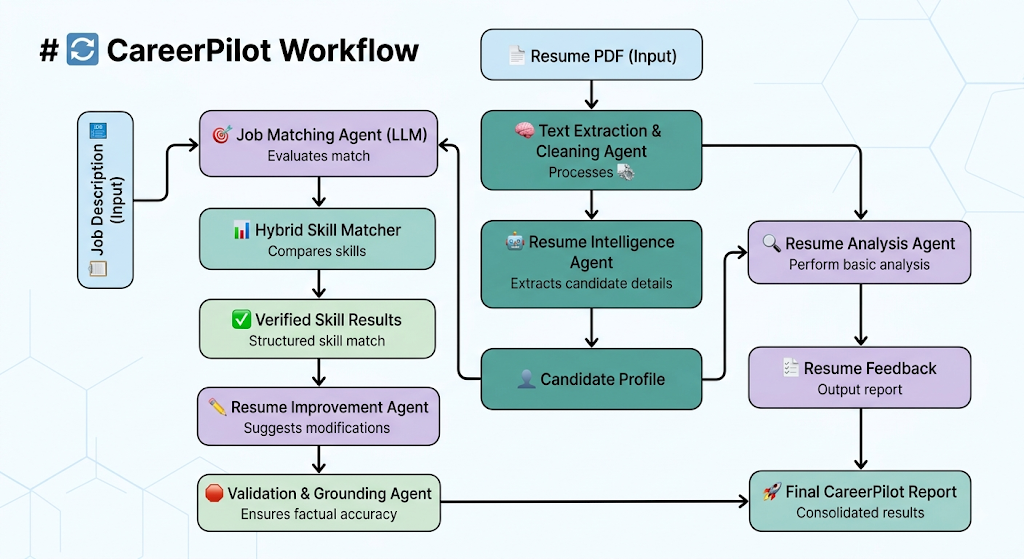

# 🧠 Key Concepts Used in CareerPilot

CareerPilot combines traditional programming with NLP, LLMs, embeddings,
semantic similarity, and validation techniques.

The most important concepts used in the project are:

1. Large Language Models (LLMs)
2. Natural Language Processing (NLP)
3. Text Embeddings
4. Semantic Similarity
5. Hybrid Skill Matching
6. LLM Output Validation and Grounding
7. Agentic AI Workflow

## 1. Large Language Models (LLMs)

A Large Language Model (LLM) is an AI model trained on large amounts of
text that can understand and generate human-like language.

CareerPilot uses an LLM through Hugging Face to perform tasks such as:

- Understanding resume content
- Creating a structured candidate profile
- Comparing the candidate with a job description
- Analyzing resume strengths and weaknesses
- Generating resume improvement suggestions

The LLM is mainly used for understanding context and working with
natural language.

In simple terms:

LLM → Understands and generates language

Python logic → Handles structured processing and verification

## 2. Natural Language Processing (NLP)

Natural Language Processing (NLP) is the field of AI that focuses on
helping computers understand and work with human language.

CareerPilot works with natural-language information such as:

- Resume text
- Job descriptions
- Skills
- Work experience
- Project descriptions

The LLM performs much of the language understanding, while traditional
NLP and text-processing techniques are used for cleaning, matching,
and organizing the information.

In simple terms:

NLP = Making computers able to work with human language.

## 3. Text Embeddings

An embedding converts text into a numerical representation called a
vector.

For example:

"Machine Learning"
        ↓
[0.12, -0.43, 0.87, ...]

The vector represents information about the meaning of the text.

This allows CareerPilot to compare pieces of text based on their
meaning instead of only checking whether the exact same words appear.

CareerPilot uses a sentence-transformer model to generate embeddings
for semantic skill matching.

Example:

"Machine Learning"
and
"ML development"

may have different words but can still have related meanings.

Embeddings help us capture this relationship numerically.

## 4. Semantic Similarity

Once two pieces of text are converted into embeddings, their vectors
can be compared to determine how semantically similar they are.

CareerPilot uses cosine similarity for this comparison.

A higher similarity score generally indicates that the two pieces of
text are more closely related in meaning.

Example from our testing:

FastAPI → fastapi → 1.000
React → react → 1.000

However, semantic similarity is not perfect.

During testing, some unrelated terms received moderate similarity
scores. This showed why CareerPilot should not rely only on embeddings.

This is one reason we introduced direct matching and a hybrid matching
approach.

## 5. Hybrid Skill Matching

CareerPilot combines direct matching and semantic matching instead of
depending on only one method.

### Direct Matching

Checks whether a required skill is directly present in the candidate's
resume evidence.

Example:

FastAPI → FastAPI
React → React

### Semantic Matching

Uses text embeddings to identify related concepts even when the wording
is different.

### Why use both?

Direct matching is reliable when the exact skill appears in the resume.

Semantic matching is useful when different wording is used for related
concepts.

Therefore, combining both methods gives CareerPilot a more reliable
skill verification process.

Workflow:

Required Skill
↓
Direct Match?
↓
Yes → Matched

No
↓
Semantic Matching
↓
Similarity Threshold
↓
Matched / Missing

## 6. LLM Output Validation and Grounding

LLMs can sometimes generate information that is not actually present in
the original source.

This is especially important when analyzing resumes because the system
must not invent achievements, experience, or metrics.

During testing, the improvement agent generated suggestions containing
numbers such as:

- 100+ students
- 25% improvement

These numbers were not present in the original resume.

CareerPilot therefore added a validation pipeline:

LLM Suggestion
↓
Numeric Validation
↓
Source Grounding
↓
Redundancy Check
↓
Final Verified Suggestion

This helps reduce unsupported or fabricated information in the final
resume recommendations.

# 🤖 Agentic AI Workflow

CareerPilot follows an agent-based workflow where different AI
components are responsible for different tasks.

### Resume Intelligence Agent

Understands the resume and converts it into structured candidate data.

### Job Matching Agent

Analyzes how well the candidate matches a given job description.

### Resume Analysis Agent

Identifies strengths, weaknesses, and areas that could be improved.

### Resume Improvement Agent

Generates suggestions for improving the resume.

### Validation Layer

Checks whether generated suggestions are supported by the original
resume.

Instead of:

Resume → One LLM Prompt → Final Answer

CareerPilot follows:

Resume
↓
Specialized AI Tasks
↓
Verification
↓
Final Report

This makes the workflow more structured and easier to validate.

# 🧪 Example Input

## Resume

The system receives a resume PDF containing information such as:

- Education
- Work experience
- Projects
- Technical skills
- Achievements

## Job Description

The user provides a job description containing requirements such as:

- Python
- Machine Learning
- Generative AI
- LLMs
- NumPy
- Pandas
- Scikit-learn
- Git
- GitHub
- FastAPI
- React

CareerPilot processes both inputs and compares the candidate's profile
with the requirements of the job.

In [84]:
print("=" * 60)
print("        🧪 EXAMPLE CAREERPILOT OUTPUT")
print("=" * 60)

print(f"\nCandidate: {careerpilot_report['candidate']}")

print(
    f"\nOverall Match Score: "
    f"{careerpilot_report['job_match']['combined_score']:.1f}/100"
)

print("\nVerified Matching Skills:")

for skill in careerpilot_report["job_match"]["matching_skills"]:
    print("-", skill)

print("\nVerified Missing Skills:")

missing = careerpilot_report["job_match"]["missing_skills"]

if missing:
    for skill in missing:
        print("-", skill)
else:
    print("None")

print("\nResume Strengths:")

for item in careerpilot_report["resume_analysis"]["strengths"]:
    print("-", item["description"])

print("\nVerified Resume Improvements:")

improvement_count = 0

for category, suggestions in careerpilot_report[
    "resume_improvements"
].items():

    for suggestion in suggestions:
        print("-", suggestion["description"])
        improvement_count += 1

if improvement_count == 0:
    print("No verified improvements found.")

        🧪 EXAMPLE CAREERPILOT OUTPUT

Candidate: Sudiksha Das

Overall Match Score: 94.0/100

Verified Matching Skills:
- Python
- Machine Learning
- Generative AI
- NumPy
- Pandas
- Scikit-learn
- LLMs
- Git
- GitHub
- FastAPI
- React

Verified Missing Skills:
None

Resume Strengths:
- Strong educational background in Computer Science and Engineering AI (CSE-AI) from Indira Gandhi Delhi Technical University for Women (IGDTUW)
- Gained practical experience as a Machine Learning & Generative AI Intern at IGDTUW × Anveshan Foundation
- Developed two impressive projects, Smart Cal and Lawgic, showcasing AI-powered health and legal assistance capabilities
- Proficient in a range of programming languages, including Python, C++, Java, and JavaScript, as well as AI and data technologies like NumPy, Pandas, and Scikit-learn

Verified Resume Improvements:
- Rephrase bullet points to use action verbs and more descriptive language, e.g., 'Developed and evaluated machine learning workflows using P

# ⚠️ Limitations

Although CareerPilot combines multiple validation techniques, it still
has some limitations.

### 1. LLM Dependence

The quality of some analysis depends on the LLM's ability to understand
the resume and job description correctly.

### 2. Semantic Matching Limitations

Embedding-based similarity can sometimes consider unrelated terms to be
semantically similar.

### 3. Resume Formatting

Different resume layouts, scanned PDFs, tables, or unusual formatting
may affect text extraction quality.

### 4. Score Interpretation

The CareerPilot match score is an internal scoring metric.

A score such as 94/100 does not represent a 94% probability of getting
the job.

### 5. Job Description Quality

The quality of the matching process also depends on how clearly the job
requirements are written.

# 🚀 Future Improvements

CareerPilot can be extended in several ways:

- Add support for multiple resume formats such as DOCX.
- Improve PDF and scanned-document extraction.
- Add more advanced skill and experience matching.
- Allow users to compare a resume against multiple job descriptions.
- Add job recommendation based on the candidate profile.
- Add a resume rewriting module with strict source grounding.
- Build a web interface for easier interaction.
- Store previous analyses for comparison over time.
- Add evaluation datasets to measure the accuracy of the matching system.

# 🏁 Conclusion

CareerPilot is an AI-powered career assistance workflow that combines
resume understanding, LLM-based analysis, semantic matching, and
validation techniques.

The system can:

- Extract and structure resume information
- Analyze a candidate's profile
- Compare the candidate with a job description
- Verify required skills
- Calculate a combined job-match score
- Identify resume strengths
- Generate and validate improvement suggestions

For the test case used in this notebook, CareerPilot produced a
combined match score of 94/100.

The main idea behind the project is not to rely on an LLM alone.
Instead, CareerPilot combines LLM reasoning with deterministic checks,
semantic similarity, and source-grounding to make the final results
more reliable.